<a href="https://colab.research.google.com/github/Kishan-kp-ai/Linkific-Tasks/blob/main/Day%2012/evaluationmetrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total data points: 60
Training records: 48
Testing records: 12

----------------------------------
Logistic Regression
----------------------------------
Accuracy : 91.67 %
Precision: 90.0 %
Recall   : 100.0 %
F1 Score : 94.74 %

----------------------------------
Decision Tree
----------------------------------
Accuracy : 100.0 %
Precision: 100.0 %
Recall   : 100.0 %
F1 Score : 100.0 %

MODEL COMPARISON
      Metric  Logistic Regression  Decision Tree
0   Accuracy                91.67          100.0
1  Precision                90.00          100.0
2     Recall               100.00          100.0
3   F1 Score                94.74          100.0

Logistic Regression Confusion Matrix:
[[2 1]
 [0 9]]


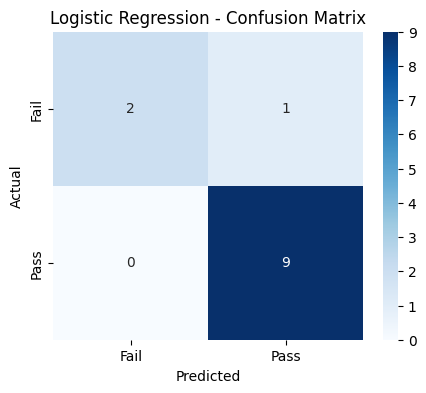


Decision Tree Confusion Matrix:
[[3 0]
 [0 9]]


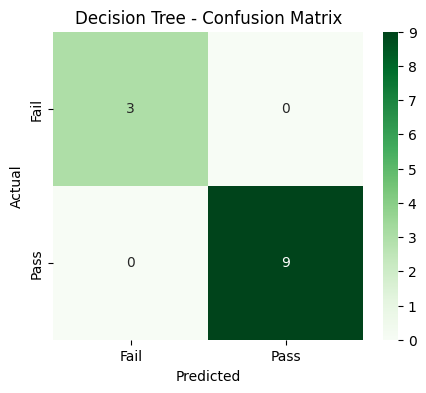


OBSERVATION
The models were evaluated using Accuracy, Precision, Recall and F1 Score.
The Confusion Matrix shows correct and incorrect Pass/Fail predictions.
For this dataset, F1 Score is useful because it considers both Precision and Recall.
Accuracy is also useful because the task is a simple Pass/Fail classification.


In [1]:
# Install Scikit-learn
!pip install scikit-learn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# --------------------------------------------------
# 1. Create Dataset - 60 Students
# --------------------------------------------------

data = {
    "Hours_Studied": [
        1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0,
        6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 2.0, 3.0,
        4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 1.5, 2.5, 3.5, 4.5,
        5.5, 6.5, 7.5, 8.5, 9.5, 10.0, 1.0, 2.5, 3.0, 4.0,
        5.0, 6.0, 7.0, 8.0, 9.0, 1.5, 3.5, 4.5, 5.5, 6.5,
        7.5, 8.5, 9.5, 2.0, 4.0, 6.0, 7.0, 8.0, 9.0, 10.0
    ],

    "Attendance": [
        55, 60, 62, 65, 68, 70, 72, 75, 78, 80,
        82, 85, 87, 90, 92, 94, 95, 96, 58, 63,
        70, 74, 79, 84, 89, 93, 52, 60, 67, 71,
        76, 81, 86, 91, 94, 97, 50, 65, 69, 73,
        78, 83, 88, 92, 95, 57, 66, 72, 77, 82,
        87, 90, 93, 61, 75, 85, 89, 94, 96, 98
    ],

    "Pass": [
        0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
        1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
        1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
        1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
        1, 1, 1, 0, 1, 1, 1, 1, 1, 1
    ]
}

# Convert to DataFrame
df = pd.DataFrame(data)

print("Total data points:", len(df))

# --------------------------------------------------
# 2. Define Features and Target
# --------------------------------------------------

X = df[["Hours_Studied", "Attendance"]]
y = df["Pass"]

# --------------------------------------------------
# 3. Split Dataset
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

# --------------------------------------------------
# 4. Train Logistic Regression
# --------------------------------------------------

logistic_model = LogisticRegression()

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

# --------------------------------------------------
# 5. Train Decision Tree
# --------------------------------------------------

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

tree_pred = decision_tree_model.predict(X_test)

# --------------------------------------------------
# 6. Evaluation Function
# --------------------------------------------------

def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    print("\n----------------------------------")
    print(model_name)
    print("----------------------------------")

    print("Accuracy :", round(accuracy * 100, 2), "%")
    print("Precision:", round(precision * 100, 2), "%")
    print("Recall   :", round(recall * 100, 2), "%")
    print("F1 Score :", round(f1 * 100, 2), "%")

    return accuracy, precision, recall, f1


# --------------------------------------------------
# 7. Evaluate Logistic Regression
# --------------------------------------------------

logistic_metrics = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred
)

# --------------------------------------------------
# 8. Evaluate Decision Tree
# --------------------------------------------------

tree_metrics = evaluate_model(
    "Decision Tree",
    y_test,
    tree_pred
)

# --------------------------------------------------
# 9. Model Comparison
# --------------------------------------------------

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Logistic Regression": [
        logistic_metrics[0],
        logistic_metrics[1],
        logistic_metrics[2],
        logistic_metrics[3]
    ],

    "Decision Tree": [
        tree_metrics[0],
        tree_metrics[1],
        tree_metrics[2],
        tree_metrics[3]
    ]
})

# Convert values to percentage
comparison["Logistic Regression"] = (
    comparison["Logistic Regression"] * 100
).round(2)

comparison["Decision Tree"] = (
    comparison["Decision Tree"] * 100
).round(2)

print("\n==================================")
print("MODEL COMPARISON")
print("==================================")

print(comparison)

# --------------------------------------------------
# 10. Confusion Matrix - Logistic Regression
# --------------------------------------------------

logistic_cm = confusion_matrix(
    y_test,
    logistic_pred
)

print("\nLogistic Regression Confusion Matrix:")
print(logistic_cm)

plt.figure(figsize=(5, 4))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --------------------------------------------------
# 11. Confusion Matrix - Decision Tree
# --------------------------------------------------

tree_cm = confusion_matrix(
    y_test,
    tree_pred
)

print("\nDecision Tree Confusion Matrix:")
print(tree_cm)

plt.figure(figsize=(5, 4))

sns.heatmap(
    tree_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --------------------------------------------------
# 12. Final Observation
# --------------------------------------------------

print("\n==================================")
print("OBSERVATION")
print("==================================")

print("The models were evaluated using Accuracy, Precision, Recall and F1 Score.")
print("The Confusion Matrix shows correct and incorrect Pass/Fail predictions.")
print("For this dataset, F1 Score is useful because it considers both Precision and Recall.")
print("Accuracy is also useful because the task is a simple Pass/Fail classification.")